# Dynamic 3DGS — Visual Experiments

This notebook turns the research note `11-dynamic-3dgs.md` into a set of small visual experiments.
The goal is to build intuition for three ideas:

- why a static Gaussian set breaks on moving scenes,
- how Dynamic 3DGS introduces time into the state,
- why temporal consistency and set operations matter.

The notebook uses 2D Gaussian splats as a teaching surrogate. The math is simpler than full 3D rendering,
but the failure modes and representation ideas are the same.


In [1]:
import warnings

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'figure.dpi': 115,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.25,
})
print('Setup complete.')


Setup complete.


### What you see

The setup cell fixes the random seed and plot style so every figure is reproducible.
That matters here because we will compare smooth motion to noisy per-frame estimates,
and small visual differences are easier to trust when the notebook is deterministic.


---

We first define a tiny Gaussian rendering toolkit.
Each primitive has a center, two scales, a rotation angle, an amplitude, and a color.
This is the 2D analogue of the Gaussian state used in 3DGS.


In [2]:
X_MIN, X_MAX = -3.0, 3.0
Y_MIN, Y_MAX = -2.4, 2.4
GRID_W, GRID_H = 220, 180


def make_grid():
    xs = np.linspace(X_MIN, X_MAX, GRID_W)
    ys = np.linspace(Y_MIN, Y_MAX, GRID_H)
    xx, yy = np.meshgrid(xs, ys)
    return xx, yy


XX, YY = make_grid()


def covariance_from_axes(scale_x, scale_y, angle_rad):
    rot = np.array([
        [np.cos(angle_rad), -np.sin(angle_rad)],
        [np.sin(angle_rad),  np.cos(angle_rad)],
    ])
    scales = np.diag([scale_x ** 2, scale_y ** 2])
    return rot @ scales @ rot.T


def gaussian_density(mean, cov, amplitude=1.0):
    pos = np.stack([XX - mean[0], YY - mean[1]], axis=-1)
    inv_cov = np.linalg.inv(cov)
    exponent = np.einsum('...i,ij,...j->...', pos, inv_cov, pos)
    return amplitude * np.exp(-0.5 * exponent)


def render_intensity(gaussians):
    image = np.zeros((GRID_H, GRID_W), dtype=float)
    for g in gaussians:
        cov = covariance_from_axes(g['sx'], g['sy'], g['theta'])
        image += gaussian_density(g['mean'], cov, g.get('amp', 1.0))
    return np.clip(image, 0.0, None)


def plot_intensity(ax, image, title):
    im = ax.imshow(
        image,
        extent=(X_MIN, X_MAX, Y_MIN, Y_MAX),
        origin='lower',
        cmap='YlOrRd',
        vmin=0.0,
        vmax=max(1.0, float(image.max())),
        aspect='auto',
    )
    ax.set_title(title)
    ax.set_xlabel('x position')
    ax.set_ylabel('y position')
    return im


def add_ellipse(ax, mean, sx, sy, theta, color, label=None, alpha=0.18):
    ell = mpatches.Ellipse(
        xy=mean,
        width=4.0 * sx,
        height=4.0 * sy,
        angle=np.degrees(theta),
        facecolor=color,
        edgecolor=color,
        linewidth=2,
        alpha=alpha,
        label=label,
    )
    ax.add_patch(ell)
    ax.scatter([mean[0]], [mean[1]], color=color, s=32, zorder=3)


def plot_state(ax, gaussians, title, annotate_ids=False):
    for idx, g in enumerate(gaussians):
        add_ellipse(ax, g['mean'], g['sx'], g['sy'], g['theta'], g['color'], label=g.get('name'))
        if annotate_ids:
            ax.text(g['mean'][0] + 0.08, g['mean'][1] + 0.08, g['name'], color=g['color'], fontsize=10)
    ax.set_xlim(X_MIN, X_MAX)
    ax.set_ylim(Y_MIN, Y_MAX)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.set_xlabel('x position')
    ax.set_ylabel('y position')


def persistent_state(t):
    means = [
        (-1.8 + 1.0 * t, 1.0 - 0.8 * t),
        (-0.2 + 1.4 * t, -0.6 + 0.9 * np.sin(np.pi * t)),
        (1.4 - 0.7 * t, 0.8 * np.cos(np.pi * t) - 0.2),
    ]
    thetas = [0.2 + 0.8 * t, -0.4 + 0.5 * t, 0.1 - 0.7 * t]
    scales = [(0.32, 0.18), (0.24, 0.16), (0.28, 0.20)]
    colors = ['#d1495b', '#2a9d8f', '#457b9d']
    names = ['G0', 'G1', 'G2']
    state = []
    for mean, theta, scale, color, name in zip(means, thetas, scales, colors, names):
        state.append({
            'mean': mean,
            'sx': scale[0],
            'sy': scale[1],
            'theta': theta,
            'amp': 1.0,
            'color': color,
            'name': name,
        })
    return state


def canonical_state():
    base_means = [(-1.3, -0.8), (-0.5, 0.9), (0.7, -0.2), (1.6, 0.7)]
    colors = ['#d1495b', '#2a9d8f', '#457b9d', '#f4a261']
    state = []
    for idx, (mean, color) in enumerate(zip(base_means, colors)):
        state.append({
            'mean': mean,
            'sx': 0.22 + 0.03 * (idx % 2),
            'sy': 0.15 + 0.02 * ((idx + 1) % 2),
            'theta': 0.0,
            'amp': 1.0,
            'color': color,
            'name': f'C{idx}',
        })
    return state


def deform_state(canonical_gaussians, t):
    deformed = []
    phase = 2.0 * np.pi * t
    for idx, g in enumerate(canonical_gaussians):
        x, y = g['mean']
        dx = 0.45 * np.sin(phase + 0.6 * idx) * (0.6 + 0.4 * abs(y))
        dy = 0.30 * np.cos(phase + 0.3 * idx) * (0.4 + 0.5 * abs(x))
        theta = g['theta'] + 0.45 * np.sin(phase + idx)
        sx = g['sx'] * (1.0 + 0.12 * np.sin(phase + idx))
        sy = g['sy'] * (1.0 + 0.10 * np.cos(phase + 0.5 * idx))
        deformed.append({
            **g,
            'mean': (x + dx, y + dy),
            'sx': sx,
            'sy': sy,
            'theta': theta,
        })
    return deformed

print('Helper functions ready.')


Helper functions ready.


### What you see

The helper cell builds the small visual language used in the rest of the notebook.
A Gaussian is represented by its mean, anisotropic scale, and rotation,
which is enough to mimic the parts of 3DGS that matter for motion intuition.


---

## Experiment 1: Why does a static Gaussian set fail on moving scenes?

Question this answers: if the underlying scene moves but the Gaussian set is forced to stay static,
what kind of visual error should we expect?

We compare a moving ground-truth blob against a static approximation that places fixed Gaussians
at several time-averaged locations. This is a simple way to visualize blur and ghosting.


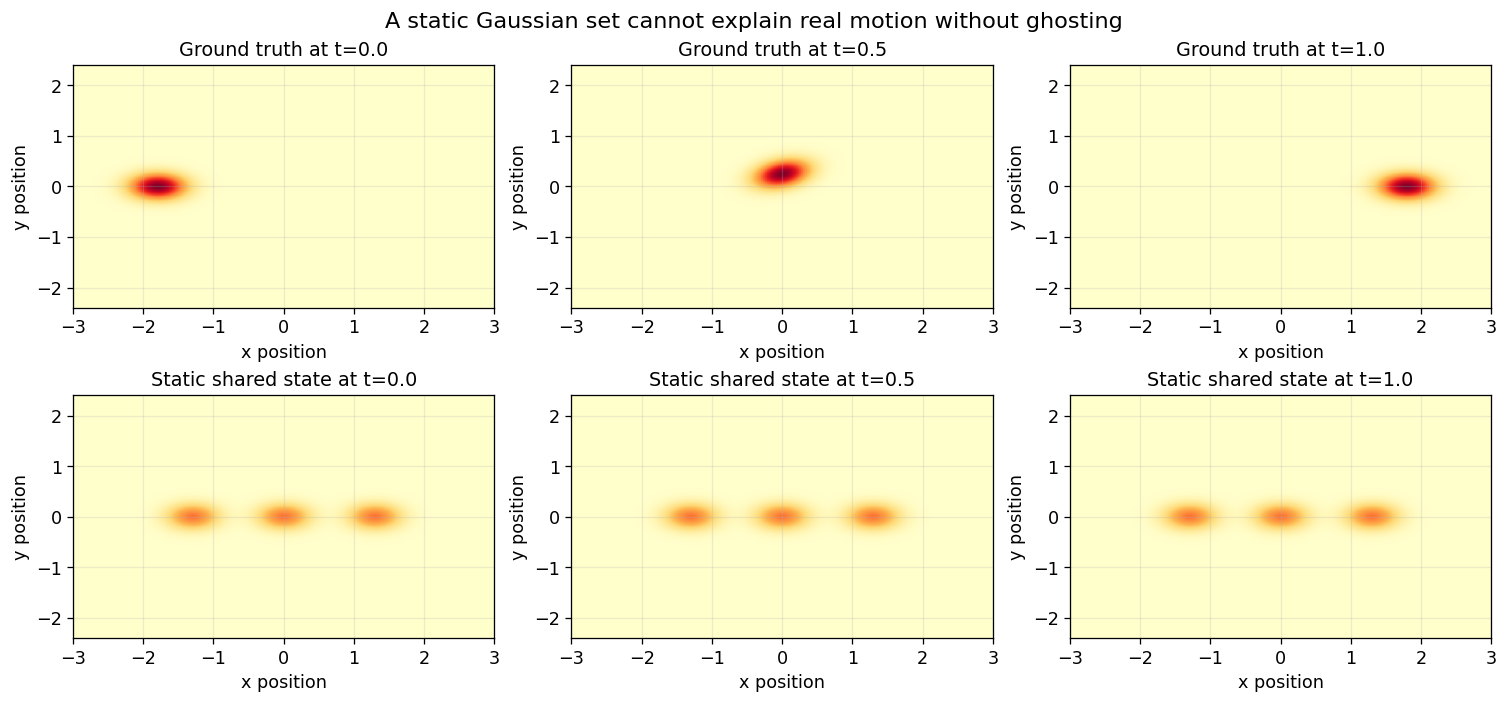

In [3]:
frame_times = [0.0, 0.5, 1.0]


def moving_blob(t):
    x = -1.8 + 3.6 * t
    y = 0.25 * np.sin(np.pi * t)
    return [{
        'mean': (x, y),
        'sx': 0.28,
        'sy': 0.18,
        'theta': 0.35 * np.sin(np.pi * t),
        'amp': 1.2,
        'color': '#d1495b',
        'name': 'moving',
    }]


static_compromise = []
for x in (-1.3, 0.0, 1.3):
    static_compromise.append({
        'mean': (x, 0.0),
        'sx': 0.26,
        'sy': 0.18,
        'theta': 0.0,
        'amp': 0.55,
        'color': '#d1495b',
        'name': 'ghost',
    })

fig, axes = plt.subplots(2, 3, figsize=(13, 6), constrained_layout=True)
for col, t in enumerate(frame_times):
    gt_img = render_intensity(moving_blob(t))
    static_img = render_intensity(static_compromise)
    plot_intensity(axes[0, col], gt_img, f'Ground truth at t={t:.1f}')
    plot_intensity(axes[1, col], static_img, f'Static shared state at t={t:.1f}')
fig.suptitle('A static Gaussian set cannot explain real motion without ghosting', fontsize=14)
plt.show()


### What you see

The top row is a true moving scene: one Gaussian changes position over time.
The bottom row reuses the same static Gaussian set for every frame, so the motion gets baked into a permanent multi-blob trace.

This is exactly the failure mode that motivates Dynamic 3DGS.
A static set can sometimes average over time well enough to reduce training loss,
but it cannot preserve a coherent state for each individual frame.
The result is ghosting: several weak copies of the object exist at once.


---

## Experiment 2: What does a persistent dynamic Gaussian state look like?

Question this answers: how do we represent motion when the *same* Gaussian keeps its identity over time?

Here each Gaussian has a stable name and color, but its mean and orientation change with time.
This is the persistent-tracking view of Dynamic 3DGS.


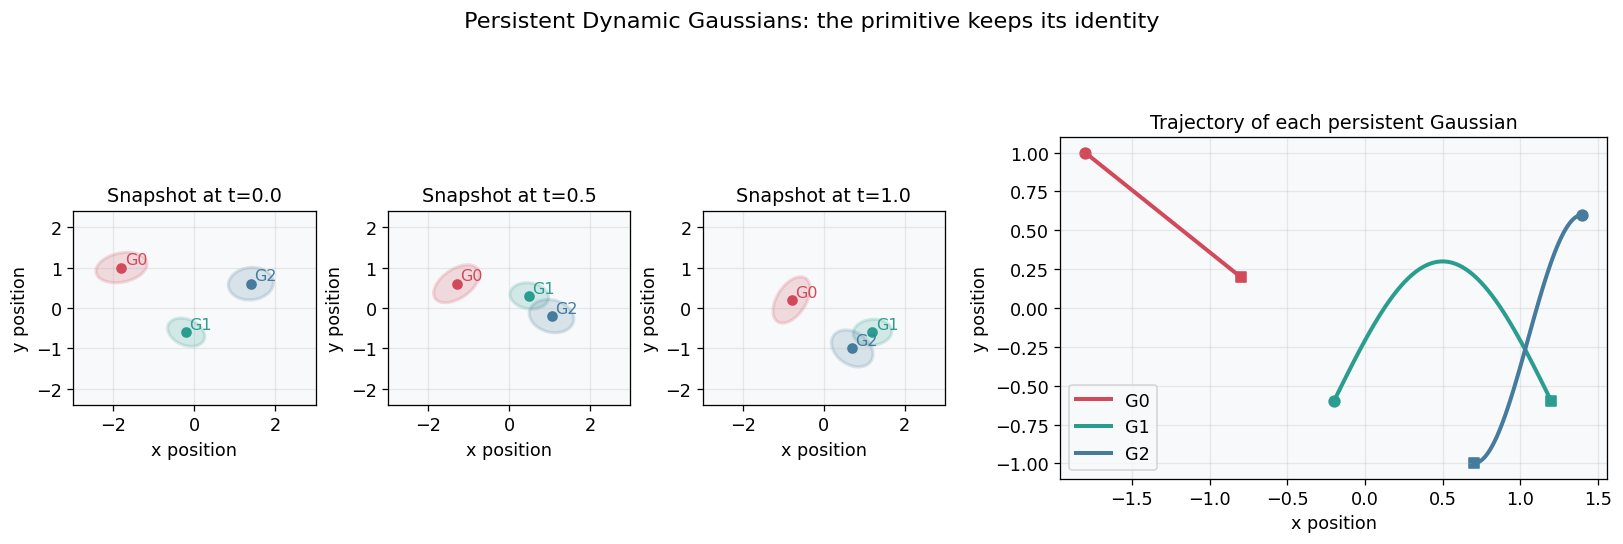

In [4]:
traj_times = np.linspace(0.0, 1.0, 60)
all_states = [persistent_state(t) for t in traj_times]

fig = plt.figure(figsize=(14, 5), constrained_layout=True)
subfigs = fig.subfigures(1, 2, width_ratios=[1.45, 1.0])
left_axes = subfigs[0].subplots(1, 3)
right_ax = subfigs[1].subplots(1, 1)

snapshot_times = [0.0, 0.5, 1.0]
for ax, t in zip(left_axes, snapshot_times):
    plot_state(ax, persistent_state(t), f'Snapshot at t={t:.1f}', annotate_ids=True)

colors = ['#d1495b', '#2a9d8f', '#457b9d']
labels = ['G0', 'G1', 'G2']
for idx, (color, label) in enumerate(zip(colors, labels)):
    xs = [state[idx]['mean'][0] for state in all_states]
    ys = [state[idx]['mean'][1] for state in all_states]
    right_ax.plot(xs, ys, color=color, linewidth=2.5, label=label)
    right_ax.scatter(xs[0], ys[0], color=color, marker='o', s=45)
    right_ax.scatter(xs[-1], ys[-1], color=color, marker='s', s=45)
right_ax.set_title('Trajectory of each persistent Gaussian')
right_ax.set_xlabel('x position')
right_ax.set_ylabel('y position')
right_ax.legend()
right_ax.set_aspect('equal')

fig.suptitle('Persistent Dynamic Gaussians: the primitive keeps its identity', fontsize=14)
plt.show()


### What you see

The three snapshots show the same named Gaussians `G0`, `G1`, and `G2` at different times.
The trajectory plot on the right makes the key idea explicit: motion is not re-discovered from scratch each frame.
Instead, each primitive follows a time-indexed path.

This is why the persistent formulation is attractive for tracking and world modeling.
If the identity of a primitive survives through time, then the latent state can describe not only *where* matter is,
but also *which piece of the scene* it still corresponds to.


---

## Experiment 3: How does canonical state plus deformation differ from persistent tracking?

Question this answers: instead of storing a full trajectory for each Gaussian,
can we keep one canonical state and generate the current state with a deformation rule?

We start from a canonical Gaussian set and apply a smooth time-dependent deformation to every primitive.


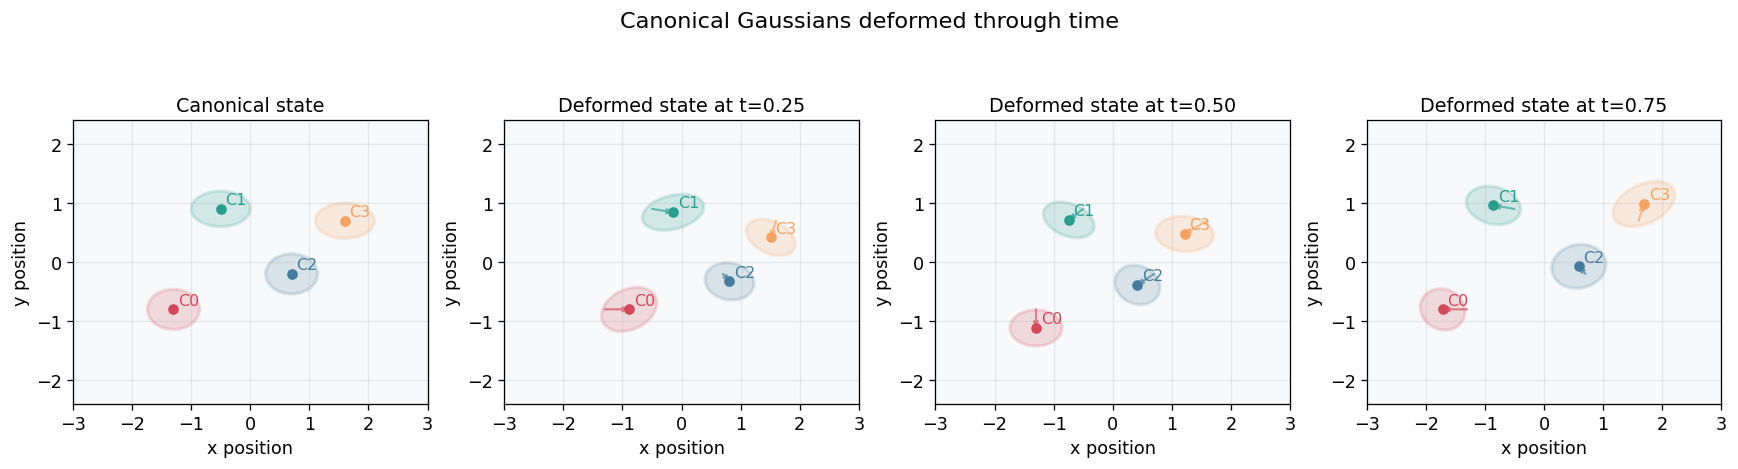

In [5]:
canonical = canonical_state()
view_times = [0.0, 0.25, 0.5, 0.75]
fig, axes = plt.subplots(1, 4, figsize=(15, 4.2), constrained_layout=True)

plot_state(axes[0], canonical, 'Canonical state', annotate_ids=True)
for ax, t in zip(axes[1:], view_times[1:]):
    deformed = deform_state(canonical, t)
    plot_state(ax, deformed, f'Deformed state at t={t:.2f}', annotate_ids=True)
    for base, moved in zip(canonical, deformed):
        ax.arrow(
            base['mean'][0],
            base['mean'][1],
            moved['mean'][0] - base['mean'][0],
            moved['mean'][1] - base['mean'][1],
            color=moved['color'],
            width=0.01,
            head_width=0.08,
            alpha=0.55,
            length_includes_head=True,
        )
fig.suptitle('Canonical Gaussians deformed through time', fontsize=14)
plt.show()


### What you see

The first panel is a canonical configuration: a single template scene.
Each later panel shows the same template pushed through a smooth deformation field.
The arrows make it clear that the dynamic state is derived from a *shared reference*, not stored independently for every frame.

This is the main appeal of canonical Dynamic 3DGS variants.
They separate stable structure from time-dependent motion,
which can be more compact and easier to interpolate than fitting a separate 3DGS scene for each timestamp.


---

## Experiment 4: Why is temporal consistency the central problem?

Question this answers: what is the difference between a smooth time-aware state model
and a per-frame fit that explains each image independently?

We compare a clean trajectory against a noisy per-frame estimate with the same overall trend.


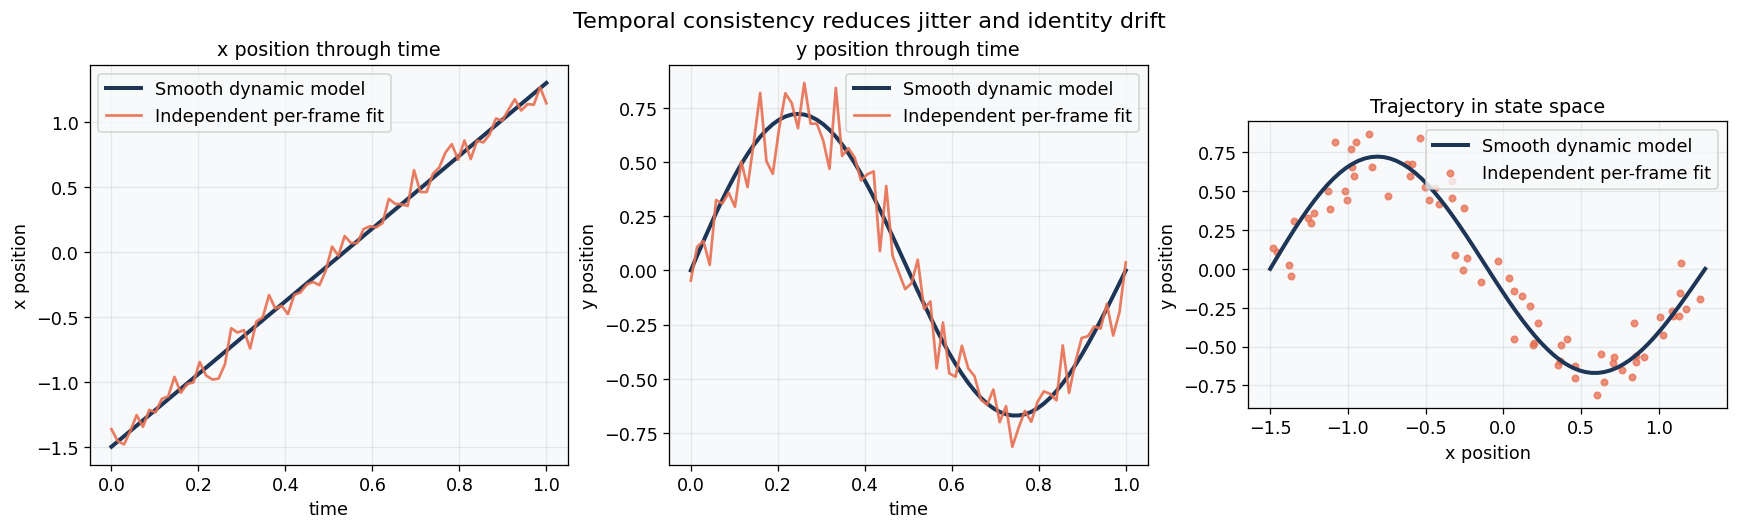

In [6]:
np.random.seed(7)
ts = np.linspace(0.0, 1.0, 70)
true_xy = np.column_stack([
    -1.5 + 2.8 * ts,
    0.75 * np.sin(2.0 * np.pi * ts) * np.exp(-0.15 * ts),
])
noisy_xy = true_xy + np.random.normal(scale=[0.08, 0.10], size=true_xy.shape)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), constrained_layout=True)
axes[0].plot(ts, true_xy[:, 0], color='#1d3557', linewidth=2.5, label='Smooth dynamic model')
axes[0].plot(ts, noisy_xy[:, 0], color='#e76f51', linewidth=1.7, alpha=0.9, label='Independent per-frame fit')
axes[0].set_title('x position through time')
axes[0].set_xlabel('time')
axes[0].set_ylabel('x position')
axes[0].legend()

axes[1].plot(ts, true_xy[:, 1], color='#1d3557', linewidth=2.5, label='Smooth dynamic model')
axes[1].plot(ts, noisy_xy[:, 1], color='#e76f51', linewidth=1.7, alpha=0.9, label='Independent per-frame fit')
axes[1].set_title('y position through time')
axes[1].set_xlabel('time')
axes[1].set_ylabel('y position')
axes[1].legend()

axes[2].plot(true_xy[:, 0], true_xy[:, 1], color='#1d3557', linewidth=2.5, label='Smooth dynamic model')
axes[2].scatter(noisy_xy[:, 0], noisy_xy[:, 1], color='#e76f51', s=16, alpha=0.75, label='Independent per-frame fit')
axes[2].set_title('Trajectory in state space')
axes[2].set_xlabel('x position')
axes[2].set_ylabel('y position')
axes[2].legend()
axes[2].set_aspect('equal')

fig.suptitle('Temporal consistency reduces jitter and identity drift', fontsize=14)
plt.show()


### What you see

Both models roughly follow the same motion pattern, but the noisy per-frame fit jitters around the smooth curve.
That jitter is small in isolation, yet it becomes very visible when rendered as video because position, rotation,
and appearance no longer evolve coherently.

This is why Dynamic 3DGS papers spend so much effort on rigidity, smoothness, and correspondence regularization.
A model that renders each frame well but changes identity or geometry unpredictably is not a stable temporal representation.


---

## Experiment 5: Why do dynamic scenes push us toward Gaussian set operations?

Question this answers: what happens when new content appears or disappears over time?

We simulate a scene where a third object emerges late in the sequence.
A fixed-cardinality state cannot express that cleanly, while an adaptive set can add a new Gaussian when needed.


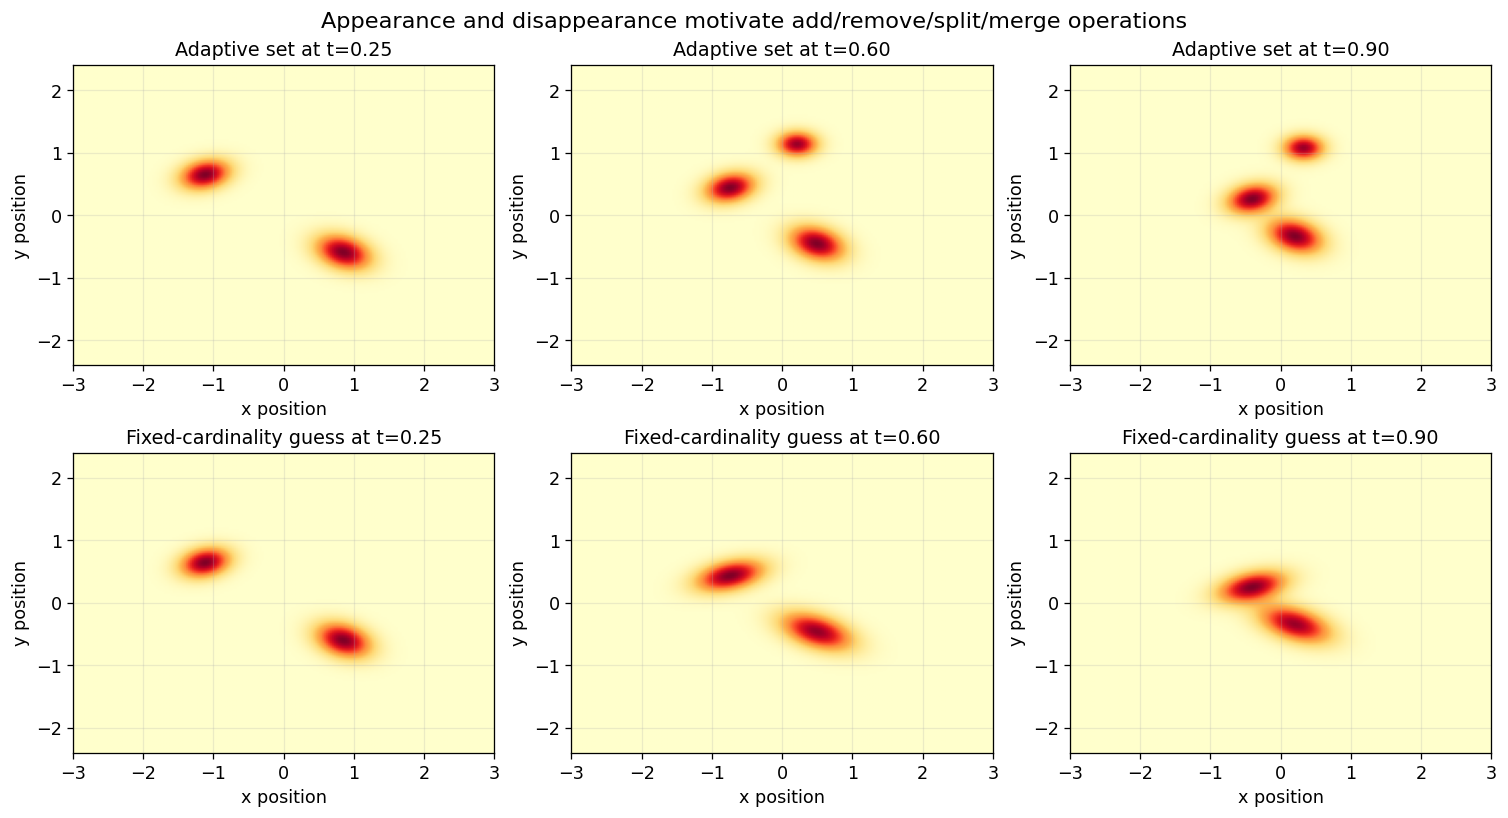

In [7]:
scene_times = [0.25, 0.60, 0.90]


def scene_with_birth(t):
    gaussians = [
        {'mean': (-1.4 + 1.1 * t, 0.8 - 0.6 * t), 'sx': 0.25, 'sy': 0.16, 'theta': 0.25, 'amp': 1.0, 'color': '#2a9d8f', 'name': 'A'},
        {'mean': (1.1 - 1.0 * t, -0.7 + 0.4 * t), 'sx': 0.28, 'sy': 0.18, 'theta': -0.35, 'amp': 1.0, 'color': '#457b9d', 'name': 'B'},
    ]
    if t >= 0.55:
        gaussians.append({'mean': (0.2 + 0.35 * (t - 0.55), 1.15 - 0.2 * (t - 0.55)), 'sx': 0.20, 'sy': 0.14, 'theta': 0.0, 'amp': 0.95, 'color': '#d1495b', 'name': 'C'})
    return gaussians


def fixed_cardinality_guess(t):
    gaussians = [
        {'mean': (-1.4 + 1.1 * t, 0.8 - 0.6 * t), 'sx': 0.25, 'sy': 0.16, 'theta': 0.25, 'amp': 1.0, 'color': '#2a9d8f', 'name': 'A'},
        {'mean': (1.1 - 1.0 * t, -0.7 + 0.4 * t), 'sx': 0.28, 'sy': 0.18, 'theta': -0.35, 'amp': 1.0, 'color': '#457b9d', 'name': 'B'},
    ]
    if t >= 0.55:
        gaussians[0]['amp'] = 1.25
        gaussians[1]['amp'] = 1.20
        gaussians[0]['sx'] *= 1.35
        gaussians[1]['sx'] *= 1.30
    return gaussians

fig, axes = plt.subplots(2, 3, figsize=(13, 7), constrained_layout=True)
for col, t in enumerate(scene_times):
    adaptive_img = render_intensity(scene_with_birth(t))
    fixed_img = render_intensity(fixed_cardinality_guess(t))
    plot_intensity(axes[0, col], adaptive_img, f'Adaptive set at t={t:.2f}')
    plot_intensity(axes[1, col], fixed_img, f'Fixed-cardinality guess at t={t:.2f}')
fig.suptitle('Appearance and disappearance motivate add/remove/split/merge operations', fontsize=14)
plt.show()


### What you see

Before the new object appears, both models look similar.
After the emergence event, the adaptive set simply adds a third Gaussian,
while the fixed-cardinality approximation tries to absorb the new mass by inflating the old primitives.
That makes the scene blurrier and less semantically clean.

This is the bridge from Dynamic 3DGS to the next topic in the roadmap: Gaussian set operations.
Once the world changes its topology or visibility pattern, a good latent state often needs the ability to add,
remove, split, or merge primitives instead of forcing every event into a fixed set.


---

## Summary / Key Takeaways

- A static Gaussian set cannot explain real motion without leaving blur or ghost copies behind.
- Persistent Dynamic 3DGS keeps primitive identity over time, which is useful for tracking and world modeling.
- Canonical-plus-deformation formulations compress motion into a time-dependent transformation of a shared base state.
- Temporal consistency is not a cosmetic detail; it is what prevents jitter, drift, and frame-wise re-invention of the scene.
- Dynamic scenes naturally lead to Gaussian set operations because appearance, disappearance, and topology change are hard to express with a fixed primitive inventory.
